# Results

Final results, comparison table, and all evaluation plots.

In [1]:
import os

PROJECT_ROOT = os.path.expanduser("~/Documents/entity-resolution-pipeline")
os.chdir(PROJECT_ROOT)

import json
import pandas as pd
from IPython.display import Image, display, Markdown

with open("results/results.json") as f:
    results = json.load(f)

m = results["model"]
b = results["baseline"]

comparison = pd.DataFrame([
    {"Model": "LightGBM (this repo)", "F1": m["f1"], "Precision": m["precision"],
     "Recall": m["recall"], "AUC-PR": m["average_precision"], "AUC-ROC": m["auc_roc"]},
    {"Model": f"Baseline ({b['baseline_feature']})", "F1": b["f1"], "Precision": b["precision"],
     "Recall": b["recall"], "AUC-PR": b["average_precision"], "AUC-ROC": b["auc_roc"]},
    {"Model": "DeepMatcher (published)", "F1": 0.693, "Precision": None,
     "Recall": None, "AUC-PR": None, "AUC-ROC": None},
    {"Model": "Ditto (published)", "F1": 0.753, "Precision": None,
     "Recall": None, "AUC-PR": None, "AUC-ROC": None},
]).set_index("Model").round(3)

print(f"Blocking recall ceiling: {results['blocking_recall_ceiling']:.3f}")
print(f"Brier score: {m['brier_score']:.4f}")
print()
display(comparison)

Blocking recall ceiling: 1.000
Brier score: 0.0550



,F1,Precision,Recall,AUC-PR,AUC-ROC
Model,,,,,
LightGBM (this repo),0.613,0.545,0.701,0.621,0.934
Baseline (token_sort_ratio),0.413,0.348,0.509,0.335,0.754
DeepMatcher (published),0.693,NaN,NaN,NaN,NaN
Ditto (published),0.753,NaN,NaN,NaN,NaN


## Evaluation Plots

### Pr Curve

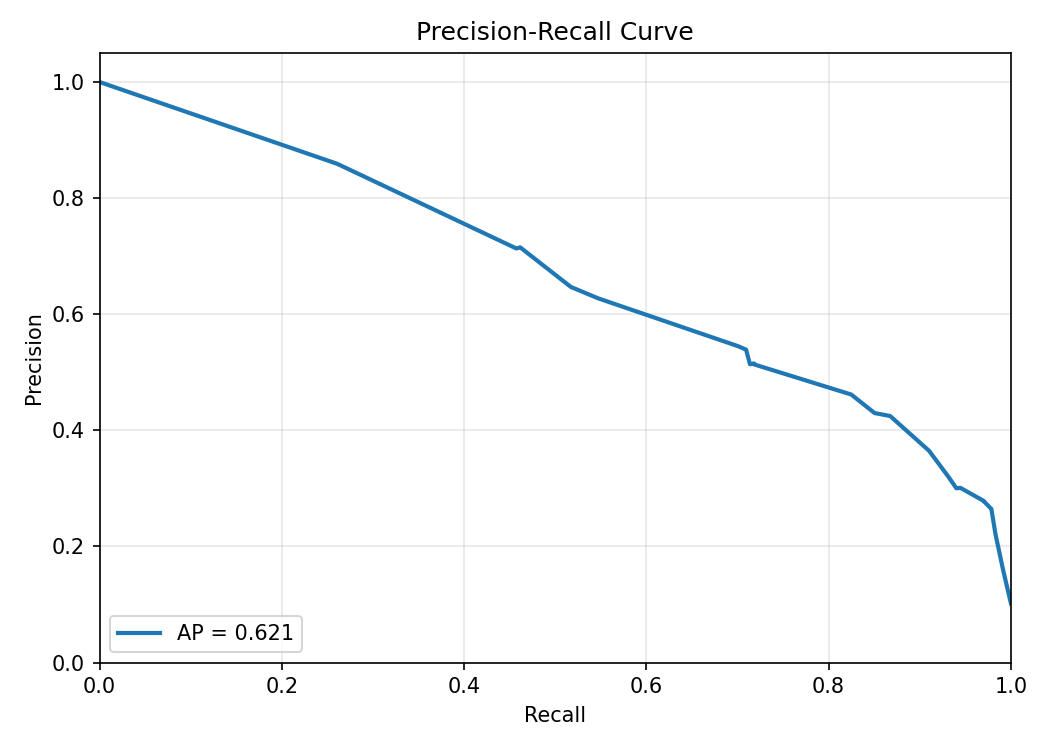

### Calibration Curve

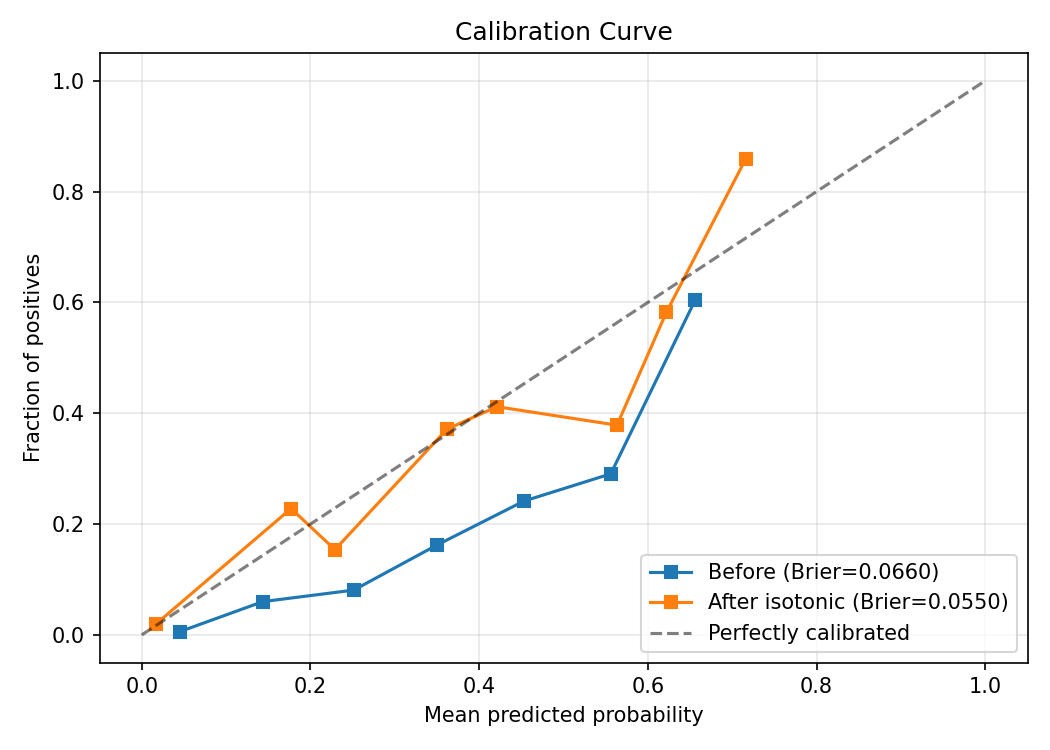

### Confusion Matrix

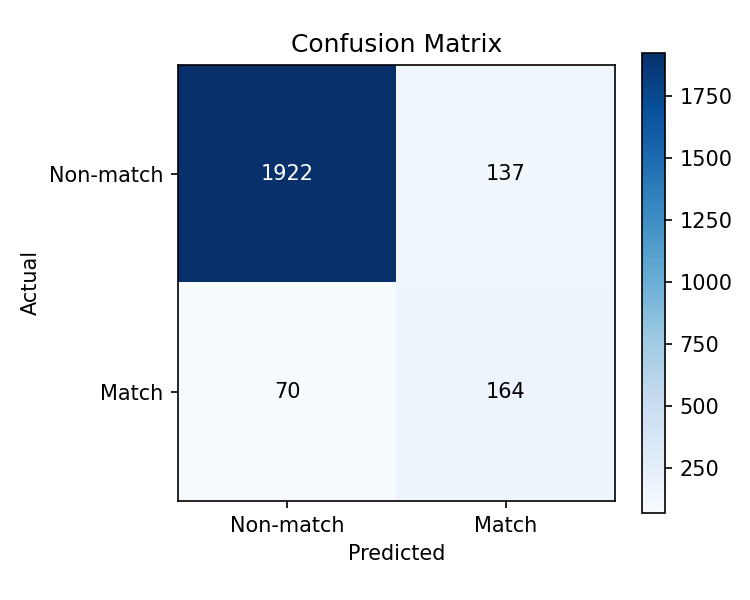

### Feature Importance

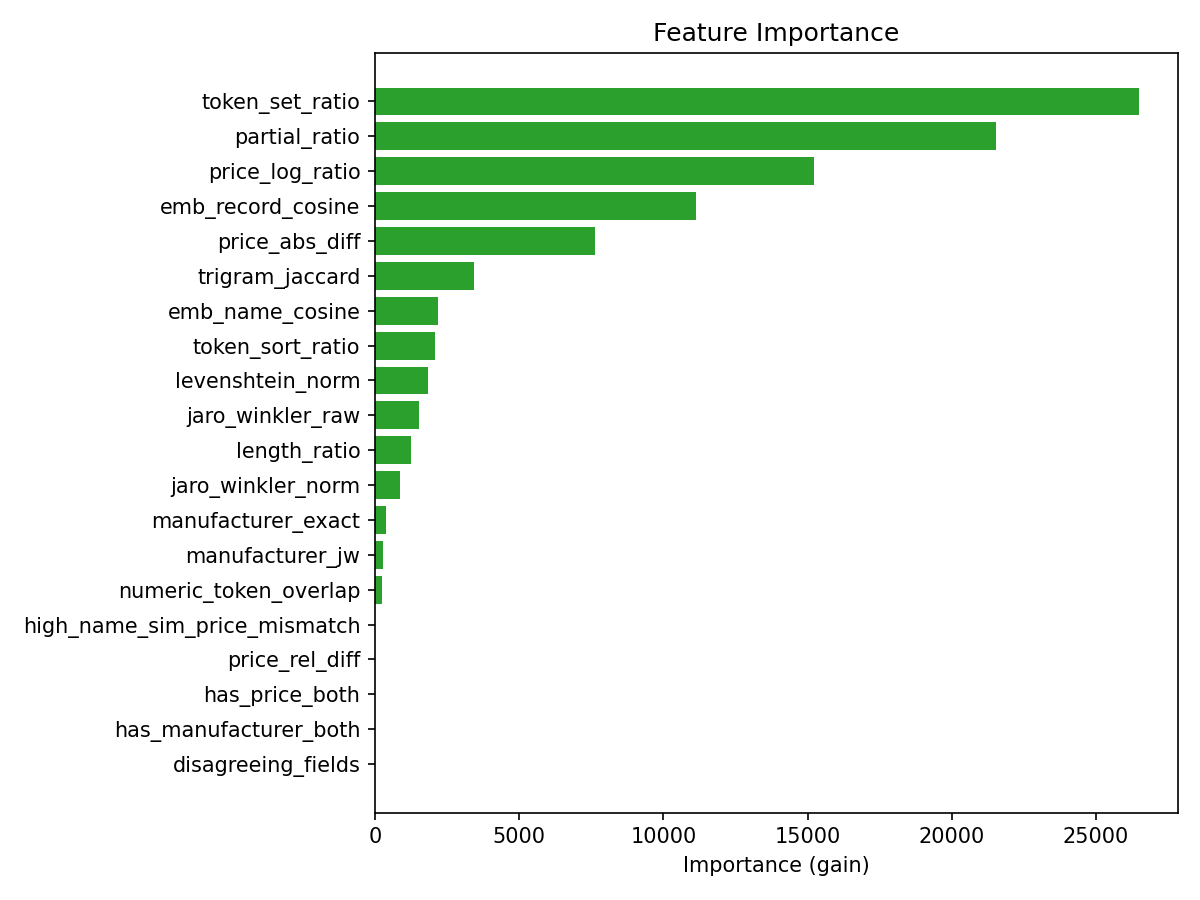

In [2]:
plots = ["pr_curve.png", "calibration_curve.png", "confusion_matrix.png", "feature_importance.png"]
for p in plots:
    display(Markdown(f"### {p.replace('.png', '').replace('_', ' ').title()}"))
    display(Image(filename=f"results/{p}"))